# CatBoost Optimization & Robust Validation

In this notebook, we will optimize our current CatBoost model and test whether its performance generalizes across different time periods.

We will tune the model systematically using time based validation, compare the optimized model against our current CatBoost benchmark, and identify a final model configuration before moving to final forecasting and submission.

In [19]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt

from pathlib import Path

DATA_DIR = Path("../data")

train = pd.read_csv(DATA_DIR / "train.csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")
test = pd.read_csv(DATA_DIR / "test_input.csv")

for df in [train, validation, test]:
    df["datetime"] = pd.to_datetime(
        df["datetime"],
        format="%d-%m-%Y %H:%M"
    )

sys.path.append(str(Path.cwd().parent))

from src.features import build_features, get_model_features, TARGETS

train_fe = build_features(train)
validation_fe = build_features(validation)
test_fe = build_features(test)

model_features = get_model_features(train_fe)

print("Features:", len(model_features))

Features: 110


In [2]:
from sklearn.model_selection import TimeSeriesSplit

X = train_fe[model_features]

tscv = TimeSeriesSplit(
    n_splits=3,
    test_size=168
)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    print(
        f"Fold {fold}: "
        f"train={len(train_idx)}, "
        f"validation={len(val_idx)}"
    )

Fold 1: train=33839, validation=168
Fold 2: train=34007, validation=168
Fold 3: train=34175, validation=168


In [3]:
train_fe = train_fe.sort_values("datetime").reset_index(drop=True)

print("Chronological:", train_fe["datetime"].is_monotonic_increasing)

Chronological: True


In [4]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

fold_results = []

tscv = TimeSeriesSplit(
    n_splits=3,
    test_size=168
)

for fold, (train_idx, val_idx) in enumerate(tscv.split(train_fe), 1):
    
    fold_train = train_fe.iloc[train_idx]
    fold_val = train_fe.iloc[val_idx]

    print(f"\n===== Fold {fold} =====")

    for target in TARGETS:
        model = CatBoostRegressor(
            iterations=500,
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            random_seed=42,
            verbose=False,
            thread_count=-1
        )

        model.fit(
            fold_train[model_features],
            fold_train[target]
        )

        y_true = fold_val[target]
        y_pred = model.predict(fold_val[model_features])

        fold_results.append({
            "Fold": fold,
            "Target": target,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAPE (%)": np.mean(
                np.abs((y_true - y_pred) / y_true)
            ) * 100,
            "R²": r2_score(y_true, y_pred)
        })

robust_baseline = pd.DataFrame(fold_results)

display(robust_baseline.round(4))


===== Fold 1 =====

===== Fold 2 =====

===== Fold 3 =====


,Fold,Target,MAE,RMSE,MAPE (%),R²
0,1,nat_demand,20.6695,26.0171,1.6654,0.9806
1,1,load_tocumen_mwh,16.8649,21.3652,1.6587,0.9806
2,1,load_santiago_mwh,1.4209,1.7583,1.8291,0.9781
3,1,load_david_mwh,2.5408,3.1847,1.7708,0.9781
4,2,nat_demand,27.7789,41.7328,2.2035,0.9401
5,2,load_tocumen_mwh,23.4525,36.6983,2.2740,0.9316
6,2,load_santiago_mwh,1.8842,2.8040,2.3819,0.9321
7,2,load_david_mwh,3.3823,4.8606,2.3414,0.9379
8,3,nat_demand,26.0258,37.2306,2.3196,0.9497
9,3,load_tocumen_mwh,21.5455,30.2089,2.3333,0.9512


In [5]:
print("=== Average across folds ===")

display(
    robust_baseline
    .groupby("Target")[["MAE", "RMSE", "MAPE (%)", "R²"]]
    .mean()
    .round(4)
)

=== Average across folds ===


,MAE,RMSE,MAPE (%),R²
Target,,,,
load_david_mwh,2.9756,4.0734,2.1369,0.9556
load_santiago_mwh,1.6527,2.2821,2.1680,0.9540
load_tocumen_mwh,20.6209,29.4241,2.0887,0.9545
nat_demand,24.8247,34.9935,2.0628,0.9568


In [6]:
robust_baseline.to_csv(
    "../outputs/metrics/catboost_robust_baseline.csv",
    index=False
)

In [7]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

param_configs = [
    {
        "name": "CB_1",
        "iterations": 800,
        "depth": 5,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    {
        "name": "CB_2",
        "iterations": 800,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    {
        "name": "CB_3",
        "iterations": 800,
        "depth": 7,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    {
        "name": "CB_4",
        "iterations": 1000,
        "depth": 6,
        "learning_rate": 0.03,
        "l2_leaf_reg": 5
    },
    {
        "name": "CB_5",
        "iterations": 1000,
        "depth": 7,
        "learning_rate": 0.03,
        "l2_leaf_reg": 5
    }
]

tuning_results = []

tscv = TimeSeriesSplit(n_splits=3, test_size=168)

for config in param_configs:

    print(f"\n========== {config['name']} ==========")

    for fold, (train_idx, val_idx) in enumerate(tscv.split(train_fe), 1):

        fold_train = train_fe.iloc[train_idx]
        fold_val = train_fe.iloc[val_idx]

        for target in TARGETS:

            model = CatBoostRegressor(
                iterations=config["iterations"],
                depth=config["depth"],
                learning_rate=config["learning_rate"],
                l2_leaf_reg=config["l2_leaf_reg"],
                loss_function="RMSE",
                random_seed=42,
                verbose=False,
                thread_count=-1
            )

            model.fit(
                fold_train[model_features],
                fold_train[target],
                eval_set=(fold_val[model_features], fold_val[target]),
                use_best_model=True
            )

            y_true = fold_val[target]
            y_pred = model.predict(fold_val[model_features])

            tuning_results.append({
                "Config": config["name"],
                "Fold": fold,
                "Target": target,
                "MAE": mean_absolute_error(y_true, y_pred),
                "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
                "MAPE (%)": np.mean(
                    np.abs((y_true - y_pred) / y_true)
                ) * 100,
                "R²": r2_score(y_true, y_pred)
            })

tuning_results = pd.DataFrame(tuning_results)

print("\n=== CONFIGURATION COMPARISON ===")

summary = (
    tuning_results
    .groupby("Config")[["MAE", "RMSE", "MAPE (%)", "R²"]]
    .mean()
    .sort_values("MAPE (%)")
)

display(summary.round(4))


========== CB_1 ==========

========== CB_2 ==========

========== CB_3 ==========

========== CB_4 ==========

========== CB_5 ==========

=== CONFIGURATION COMPARISON ===


,MAE,RMSE,MAPE (%),R²
Config,,,,
CB_2,12.3133,17.3287,2.0675,0.9577
CB_1,12.5217,17.2270,2.0924,0.9584
CB_4,12.4640,17.2806,2.1087,0.9565
CB_3,12.6917,18.0495,2.1219,0.9532
CB_5,12.7659,18.1139,2.1458,0.9524


In [8]:
per_target_summary = (
    tuning_results
    .groupby(["Target", "Config"])[["MAE", "RMSE", "MAPE (%)", "R²"]]
    .mean()
    .reset_index()
)

display(
    per_target_summary
    .sort_values(["Target", "MAPE (%)"])
    .round(4)
)

,Target,Config,MAE,RMSE,MAPE (%),R²
1,load_david_mwh,CB_2,2.8824,3.9128,2.0679,0.9587
0,load_david_mwh,CB_1,2.9270,3.9539,2.1094,0.9585
2,load_david_mwh,CB_3,2.9742,4.1679,2.1347,0.9524
3,load_david_mwh,CB_4,3.0101,4.1943,2.1581,0.9525
4,load_david_mwh,CB_5,3.0567,4.2135,2.1958,0.9513
5,load_santiago_mwh,CB_1,1.6157,2.1947,2.1062,0.9576
6,load_santiago_mwh,CB_2,1.6196,2.2003,2.1158,0.9571
7,load_santiago_mwh,CB_3,1.6420,2.2776,2.1471,0.9531
8,load_santiago_mwh,CB_4,1.6469,2.2290,2.1580,0.9563
9,load_santiago_mwh,CB_5,1.6547,2.2905,2.1641,0.9529


In [11]:
# Complete competition validation windows
window_counts = validation_fe.groupby("window_id").size()
complete_windows = window_counts[window_counts == 168].index

val_complete = validation_fe[
    validation_fe["window_id"].isin(complete_windows)
].copy()

print("Complete validation windows:", len(complete_windows))
print("Validation rows:", len(val_complete))

Complete validation windows: 34
Validation rows: 5712


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": np.mean(
            np.abs((y_true - y_pred) / y_true)
        ) * 100,
        "R²": r2_score(y_true, y_pred)
    }

In [14]:
best_configs = {
    "nat_demand": {
        "iterations": 800,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    "load_tocumen_mwh": {
        "iterations": 800,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    "load_santiago_mwh": {
        "iterations": 800,
        "depth": 5,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    "load_david_mwh": {
        "iterations": 800,
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    }
}

competition_validation_results = []

for target, params in best_configs.items():

    print(f"Training tuned model: {target}")

    model = CatBoostRegressor(
        **params,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        thread_count=-1
    )

    model.fit(
        train_fe[model_features],
        train_fe[target]
    )

    y_true = val_complete[target]
    y_pred = model.predict(val_complete[model_features])

    metrics = evaluate_predictions(y_true, y_pred)

    competition_validation_results.append({
        "Target": target,
        **metrics
    })

tuned_validation = pd.DataFrame(competition_validation_results)

display(tuned_validation.round(4))

Training tuned model: nat_demand
Training tuned model: load_tocumen_mwh
Training tuned model: load_santiago_mwh
Training tuned model: load_david_mwh


,Target,MAE,RMSE,MAPE (%),R²
0,nat_demand,44.2908,62.6787,3.9402,0.8907
1,load_tocumen_mwh,35.8900,51.0998,3.9062,0.8916
2,load_santiago_mwh,2.8619,4.0410,3.9739,0.8906
3,load_david_mwh,5.2039,7.3191,3.9683,0.8918


In [15]:
tuned_predictions = val_complete[["datetime", "horizon_hour"]].copy()

for target, params in best_configs.items():

    model = CatBoostRegressor(
        **params,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        thread_count=-1
    )

    model.fit(
        train_fe[model_features],
        train_fe[target]
    )

    tuned_predictions[f"{target}_pred"] = model.predict(
        val_complete[model_features]
    )

print(tuned_predictions.shape)

(5712, 6)


In [16]:
peak_thresholds = {
    target: train_fe[target].quantile(0.95)
    for target in TARGETS
}

peak_results = []

for target in TARGETS:

    actual = val_complete[target]
    pred = tuned_predictions[f"{target}_pred"]

    peak_mask = actual >= peak_thresholds[target]

    for period, mask in [
        ("Peak", peak_mask),
        ("Non-Peak", ~peak_mask)
    ]:
        peak_results.append({
            "Target": target,
            "Period": period,
            "MAE": mean_absolute_error(actual[mask], pred[mask]),
            "RMSE": np.sqrt(mean_squared_error(actual[mask], pred[mask])),
            "MAPE (%)": np.mean(
                np.abs((actual[mask] - pred[mask]) / actual[mask])
            ) * 100,
            "R²": r2_score(actual[mask], pred[mask])
        })

peak_results = pd.DataFrame(peak_results)

display(peak_results.round(4))

,Target,Period,MAE,RMSE,MAPE (%),R²
0,nat_demand,Peak,66.5393,78.9517,4.2124,-1.6501
1,nat_demand,Non-Peak,41.2440,60.1082,3.9029,0.8546
2,load_tocumen_mwh,Peak,53.5555,63.9877,4.1363,-1.5499
3,load_tocumen_mwh,Non-Peak,33.4908,49.0892,3.8750,0.8559
4,load_santiago_mwh,Peak,4.2787,5.0654,4.2290,-1.3953
5,load_santiago_mwh,Non-Peak,2.6517,3.8659,3.9360,0.8507
6,load_david_mwh,Peak,7.7484,9.1739,4.2163,-1.5910
7,load_david_mwh,Non-Peak,4.8276,7.0032,3.9316,0.8513


In [17]:
horizon_results = []

for target in TARGETS:
    actual = val_complete[target]
    pred = tuned_predictions[f"{target}_pred"]

    temp = pd.DataFrame({
        "horizon_hour": val_complete["horizon_hour"],
        "actual": actual.values,
        "pred": pred
    })

    temp["abs_error"] = np.abs(temp["actual"] - temp["pred"])

    horizon_mae = (
        temp.groupby("horizon_hour")["abs_error"]
        .mean()
        .reset_index(name="MAE")
    )

    horizon_mae["Target"] = target
    horizon_results.append(horizon_mae)

horizon_results = pd.concat(horizon_results, ignore_index=True)

display(horizon_results.head(20))


,horizon_hour,MAE,Target
0,1,42.575194,nat_demand
1,2,40.094870,nat_demand
2,3,41.854221,nat_demand
3,4,37.873222,nat_demand
4,5,35.528019,nat_demand
5,6,35.116370,nat_demand
6,7,34.109378,nat_demand
7,8,33.374285,nat_demand
8,9,37.547716,nat_demand
9,10,39.832454,nat_demand


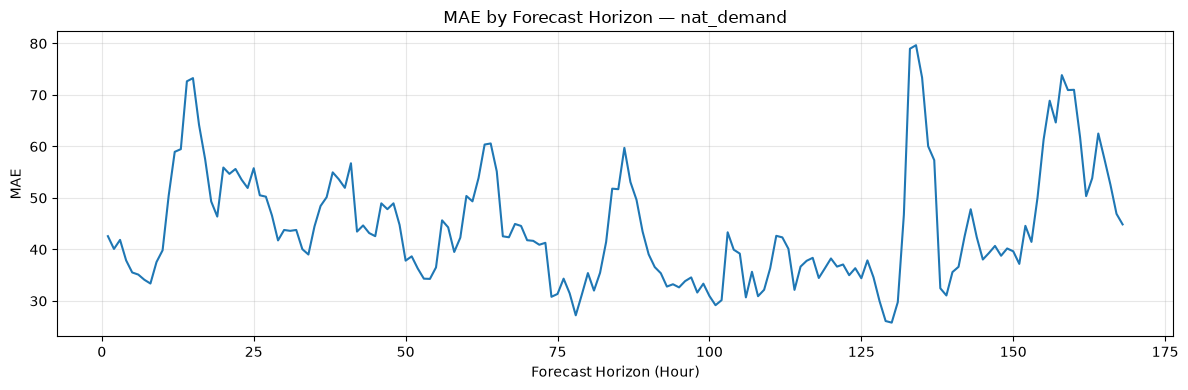

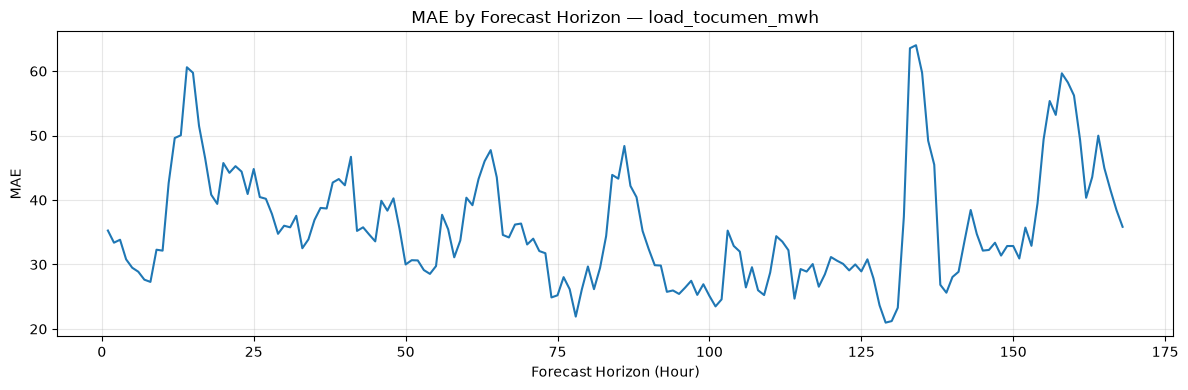

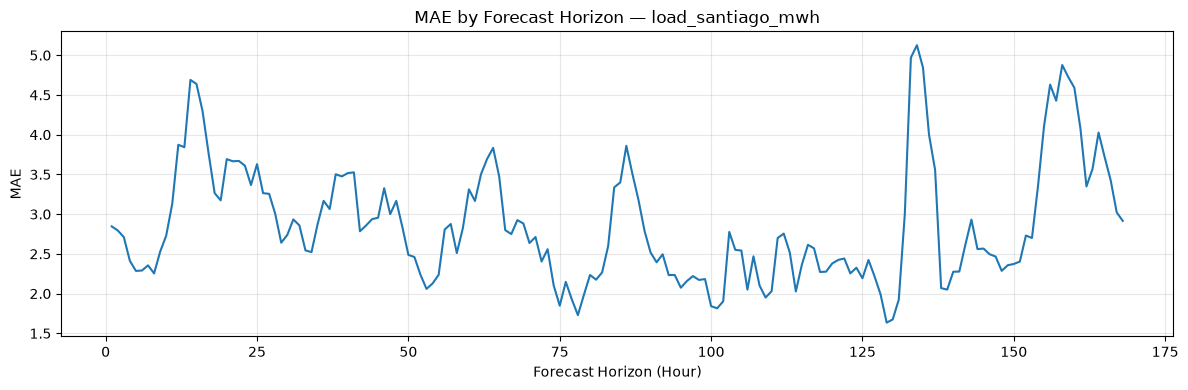

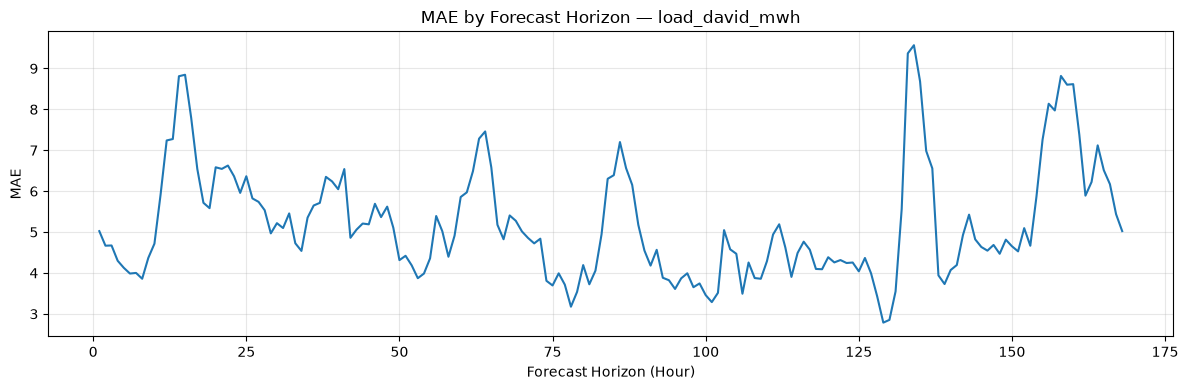

In [20]:
for target in TARGETS:
    temp = horizon_results[horizon_results["Target"] == target]

    plt.figure(figsize=(12, 4))
    plt.plot(temp["horizon_hour"], temp["MAE"])
    plt.title(f"MAE by Forecast Horizon — {target}")
    plt.xlabel("Forecast Horizon (Hour)")
    plt.ylabel("MAE")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [21]:
peak_bias_results = []

for target in TARGETS:
    actual = val_complete[target]
    pred = tuned_predictions[f"{target}_pred"]

    threshold = train_fe[target].quantile(0.95)
    peak_mask = actual >= threshold

    error = pred - actual

    peak_bias_results.append({
        "Target": target,
        "Peak_Threshold": threshold,
        "Peak_Count": peak_mask.sum(),
        "Mean_Error": error[peak_mask].mean(),
        "Mean_Absolute_Error": np.abs(error[peak_mask]).mean(),
        "Underprediction_Rate": (error[peak_mask] < 0).mean() * 100
    })

peak_bias_results = pd.DataFrame(peak_bias_results)

display(peak_bias_results.round(4))

,Target,Peak_Threshold,Peak_Count,Mean_Error,Mean_Absolute_Error,Underprediction_Rate
0,nat_demand,1495.2204,688,-64.3988,66.5393,95.0581
1,load_tocumen_mwh,1226.3443,683,-51.7449,53.5555,94.1435
2,load_santiago_mwh,95.4413,738,-4.1408,4.2787,94.7154
3,load_david_mwh,173.6629,736,-7.4864,7.7484,95.1087


In [22]:
peak_weight_results = []

for target, params in best_configs.items():

    threshold = train_fe[target].quantile(0.90)

    weights = np.where(
        train_fe[target] >= threshold,
        2.0,
        1.0
    )

    model = CatBoostRegressor(
        **params,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        thread_count=-1
    )

    model.fit(
        train_fe[model_features],
        train_fe[target],
        sample_weight=weights
    )

    y_true = val_complete[target]
    y_pred = model.predict(val_complete[model_features])

    peak_weight_results.append({
        "Target": target,
        **evaluate_predictions(y_true, y_pred)
    })

peak_weight_results = pd.DataFrame(peak_weight_results)

display(peak_weight_results.round(4))

,Target,MAE,RMSE,MAPE (%),R²
0,nat_demand,43.9664,62.1017,3.9206,0.8927
1,load_tocumen_mwh,36.1126,51.0630,3.9290,0.8918
2,load_santiago_mwh,2.8762,4.0322,3.9856,0.8911
3,load_david_mwh,5.2057,7.3108,3.9684,0.8920


In [23]:
peak_weight_predictions = val_complete[["datetime", "horizon_hour"]].copy()

for target, params in best_configs.items():

    threshold = train_fe[target].quantile(0.90)

    weights = np.where(
        train_fe[target] >= threshold,
        2.0,
        1.0
    )

    model = CatBoostRegressor(
        **params,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        thread_count=-1
    )

    model.fit(
        train_fe[model_features],
        train_fe[target],
        sample_weight=weights
    )

    peak_weight_predictions[f"{target}_pred"] = model.predict(
        val_complete[model_features]
    )

In [24]:
peak_weight_bias = []

for target in TARGETS:

    actual = val_complete[target]
    pred = peak_weight_predictions[f"{target}_pred"]

    threshold = train_fe[target].quantile(0.95)
    peak_mask = actual >= threshold

    error = pred - actual

    peak_weight_bias.append({
        "Target": target,
        "Mean_Error": error[peak_mask].mean(),
        "MAE": np.abs(error[peak_mask]).mean(),
        "Underprediction_Rate (%)": (
            error[peak_mask] < 0
        ).mean() * 100
    })

peak_weight_bias = pd.DataFrame(peak_weight_bias)

display(peak_weight_bias.round(4))

,Target,Mean_Error,MAE,Underprediction_Rate (%)
0,nat_demand,-60.8721,63.1577,93.3140
1,load_tocumen_mwh,-50.7737,52.6350,93.2650
2,load_santiago_mwh,-4.0970,4.2382,94.3089
3,load_david_mwh,-7.3340,7.6237,94.2935


In [25]:
blend_results = []

blend_weights = [0.25, 0.50, 0.75]

for w in blend_weights:
    row = {"Regular_Weight": w, "Peak_Weight": 1 - w}

    for target in TARGETS:
        y_true = val_complete[target]

        regular_pred = tuned_predictions[f"{target}_pred"]
        peak_pred = peak_weight_predictions[f"{target}_pred"]

        blended_pred = (
            w * regular_pred
            + (1 - w) * peak_pred
        )

        metrics = evaluate_predictions(y_true, blended_pred)

        row[f"{target}_MAPE"] = metrics["MAPE (%)"]
        row[f"{target}_R2"] = metrics["R²"]

    blend_results.append(row)

blend_results = pd.DataFrame(blend_results)

display(blend_results.round(4))

,Regular_Weight,Peak_Weight,nat_demand_MAPE,nat_demand_R2,load_tocumen_mwh_MAPE,load_tocumen_mwh_R2,load_santiago_mwh_MAPE,load_santiago_mwh_R2,load_david_mwh_MAPE,load_david_mwh_R2
0,0.25,0.75,3.9192,0.8925,3.9171,0.8920,3.9750,0.8913,3.9620,0.8923
1,0.50,0.50,3.9216,0.8921,3.9094,0.8921,3.9694,0.8913,3.9594,0.8924
2,0.75,0.25,3.9282,0.8915,3.9054,0.8920,3.9693,0.8910,3.9614,0.8922


In [26]:
final_candidates = {
    "Regular_CatBoost": tuned_predictions,
    "Peak_Weighted_CatBoost": peak_weight_predictions
}

# Add 50/50 blend
blend_predictions = val_complete[["datetime", "horizon_hour"]].copy()

for target in TARGETS:
    blend_predictions[f"{target}_pred"] = (
        0.50 * tuned_predictions[f"{target}_pred"]
        + 0.50 * peak_weight_predictions[f"{target}_pred"]
    )

final_candidates["50_50_Blend"] = blend_predictions

final_validation_results = []

for model_name, preds in final_candidates.items():
    for target in TARGETS:

        y_true = val_complete[target]
        y_pred = preds[f"{target}_pred"]

        metrics = evaluate_predictions(y_true, y_pred)

        final_validation_results.append({
            "Model": model_name,
            "Target": target,
            **metrics
        })

final_validation_results = pd.DataFrame(final_validation_results)

display(final_validation_results.round(4))

,Model,Target,MAE,RMSE,MAPE (%),R²
0,Regular_CatBoost,nat_demand,44.2908,62.6787,3.9402,0.8907
1,Regular_CatBoost,load_tocumen_mwh,35.8900,51.0998,3.9062,0.8916
2,Regular_CatBoost,load_santiago_mwh,2.8619,4.0410,3.9739,0.8906
3,Regular_CatBoost,load_david_mwh,5.2039,7.3191,3.9683,0.8918
4,Peak_Weighted_CatBoost,nat_demand,43.9664,62.1017,3.9206,0.8927
5,Peak_Weighted_CatBoost,load_tocumen_mwh,36.1126,51.0630,3.9290,0.8918
6,Peak_Weighted_CatBoost,load_santiago_mwh,2.8762,4.0322,3.9856,0.8911
7,Peak_Weighted_CatBoost,load_david_mwh,5.2057,7.3108,3.9684,0.8920
8,50_50_Blend,nat_demand,44.0213,62.2679,3.9216,0.8921
9,50_50_Blend,load_tocumen_mwh,35.9187,50.9814,3.9094,0.8921


In [27]:
reliability_results = []

for target in TARGETS:
    actual = val_complete[target]
    pred = blend_predictions[f"{target}_pred"]

    residual = actual - pred

    reliability_results.append({
        "Target": target,
        "Mean_Error": residual.mean(),
        "MAE": np.abs(residual).mean(),
        "P95_Abs_Error": np.percentile(np.abs(residual), 95),
        "P99_Abs_Error": np.percentile(np.abs(residual), 99),
        "P99.9_Abs_Error": np.percentile(np.abs(residual), 99.9)
    })

reliability_results = pd.DataFrame(reliability_results)

display(reliability_results.round(4))

,Target,Mean_Error,MAE,P95_Abs_Error,P99_Abs_Error,P99.9_Abs_Error
0,nat_demand,18.7528,44.0213,114.0241,166.3260,344.5654
1,load_tocumen_mwh,14.9644,35.9187,92.7812,137.5021,285.8072
2,load_santiago_mwh,1.2841,2.8609,7.2946,10.7636,22.4190
3,load_david_mwh,2.3003,5.1924,13.1221,19.3682,39.8161


In [28]:
safety_margin_results = []

for target in TARGETS:
    actual = val_complete[target].values
    pred = blend_predictions[f"{target}_pred"].values

    underprediction = np.maximum(actual - pred, 0)

    safety_margin_results.append({
        "Target": target,
        "P95_Underprediction": np.percentile(underprediction, 95),
        "P99_Underprediction": np.percentile(underprediction, 99),
        "P99.9_Underprediction": np.percentile(underprediction, 99.9)
    })

safety_margins = pd.DataFrame(safety_margin_results)

display(safety_margins.round(4))

,Target,P95_Underprediction,P99_Underprediction,P99.9_Underprediction
0,nat_demand,105.6783,155.9417,190.0934
1,load_tocumen_mwh,86.3708,128.7347,161.3513
2,load_santiago_mwh,6.7427,9.9942,12.5862
3,load_david_mwh,12.2870,18.1024,22.4917


In [31]:
import pandas as pd
from pathlib import Path

# Project data folder
DATA_DIR = Path("../data")

# Bonus datasets we want to inspect
bonus_files = [
    "system_capacity_reference.csv",
    "generator_reference_2023.csv",
    "generator_operating_limits.csv",
    "network_buses.csv",
    "optimization_parameters.csv",
    "transmission_lines.csv",
    "zone_bus_mapping.csv"
]

print("Data directory:", DATA_DIR.resolve())
print()

# Find each bonus file anywhere inside the data folder
found_files = {}

for file_name in bonus_files:
    matches = list(DATA_DIR.rglob(file_name))

    if matches:
        found_files[file_name] = matches[0]
    else:
        print(f"NOT FOUND: {file_name}")

print("\nFound bonus files:")
for name, path in found_files.items():
    print(f"{name} -> {path}")

# Inspect each found file
for file_name, file_path in found_files.items():

    print(f"\n{'=' * 70}")
    print(f"{file_name}")
    print(f"{'=' * 70}")

    df = pd.read_csv(file_path)

    print("Shape:", df.shape)
    print("Columns:")
    print(list(df.columns))

    print("\nFirst 3 rows:")
    display(df.head(3))

Data directory: C:\Users\htupk\Documents\PROJECTS\Electricity-Forecasting\data


Found bonus files:
system_capacity_reference.csv -> ..\data\system_capacity_reference.csv
generator_reference_2023.csv -> ..\data\generator_reference_2023.csv
generator_operating_limits.csv -> ..\data\Dataset for Bonus PS\generator_operating_limits.csv
network_buses.csv -> ..\data\Dataset for Bonus PS\network_buses.csv
optimization_parameters.csv -> ..\data\Dataset for Bonus PS\optimization_parameters.csv
transmission_lines.csv -> ..\data\Dataset for Bonus PS\transmission_lines.csv
zone_bus_mapping.csv -> ..\data\Dataset for Bonus PS\zone_bus_mapping.csv

system_capacity_reference.csv
Shape: (12, 3)
Columns:
['zone', 'technology', 'capacity_mw']

First 3 rows:


,zone,technology,capacity_mw
0,Tocumen,wind,223.093426
1,Tocumen,solar,175.522034
2,Tocumen,thermal,1491.937286



generator_reference_2023.csv
Shape: (70, 10)
Columns:
['record_no', 'company', 'project', 'province', 'district', 'corregimiento', 'capacity_mw', 'commercial_operation_date', 'status', 'technology']

First 3 rows:


,record_no,company,project,province,district,corregimiento,capacity_mw,commercial_operation_date,status,technology
0,1,"Island Power, S.A. (IPSA)","Sistemas Aislados ( Yavisa, Garachiné, Santa ...",Bocas del Toro; Darién; Panamá; Guna Yala,NaN,NaN,32.42,Operación,Operación,Térmicas
1,2,"Seneca Energy, S.A.",Palmas Bellas\n,Colón\n,Chagres \n,Palmas Bellas \n,1.50,Operación,Operación,Térmicas
2,3,"Seneca Energy, S.A.",\nIsla Grande,Colón\n,Portobelo,Isla Grande,1.50,Operación,Operación,Térmicas



generator_operating_limits.csv
Shape: (12, 15)
Columns:
['generator_id', 'bus_id', 'zone', 'technology', 'capacity_mw', 'min_output_mw', 'ramp_up_mw_per_h', 'ramp_down_mw_per_h', 'variable_cost_usd_per_mwh', 'startup_cost_usd', 'unserved_load_penalty_usd_per_mwh', 'emissions_kgco2_per_mwh', 'dispatchable', 'renewable', 'data_status']

First 3 rows:


...

,parameter,value,unit,description,data_status
0,minimum_load_served_fraction,0.999,fraction,At least 99.9% of forecast load must be served...,competition_rule
1,maximum_unserved_fraction,0.001,fraction,Equivalent maximum unserved-load fraction per ...,competition_rule
2,renewable_curtailment_penalty_usd_per_mwh,1.000,USD/MWh,Penalty coefficient for curtailed wind/solar i...,competition_assumption



transmission_lines.csv
Shape: (2, 8)
Columns:
['line_id', 'from_bus', 'to_bus', 'thermal_limit_mw', 'emergency_limit_mw', 'reactance_pu', 'status', 'data_status']

First 3 rows:


,line_id,from_bus,to_bus,thermal_limit_mw,emergency_limit_mw,reactance_pu,status,data_status
0,LINE_TOCUMEN_SANTIAGO,BUS_TOCUMEN,BUS_SANTIAGO,600.0,720.0,0.12,1,synthetic_competition_reference
1,LINE_SANTIAGO_DAVID,BUS_SANTIAGO,BUS_DAVID,300.0,360.0,0.10,1,synthetic_competition_reference



zone_bus_mapping.csv
Shape: (3, 5)
Columns:
['zone', 'bus_id', 'load_column', 'wind_column', 'solar_column']

First 3 rows:


,zone,bus_id,load_column,wind_column,solar_column
0,Tocumen,BUS_TOCUMEN,load_tocumen_mwh,tocumen_wind_gen_mwh,tocumen_solar_gen_mwh
1,Santiago,BUS_SANTIAGO,load_santiago_mwh,santiago_wind_gen_mwh,santiago_solar_gen_mwh
2,David,BUS_DAVID,load_david_mwh,david_wind_gen_mwh,david_solar_gen_mwh


In [32]:
# Full generator operating limits
gen_limits = pd.read_csv(found_files["generator_operating_limits.csv"])

print("=== GENERATOR LIMITS ===")
display(gen_limits)

# Optimization rules
opt_params = pd.read_csv(found_files["optimization_parameters.csv"])

print("\n=== OPTIMIZATION PARAMETERS ===")
display(opt_params)

# Transmission constraints
lines = pd.read_csv(found_files["transmission_lines.csv"])

print("\n=== TRANSMISSION LINES ===")
display(lines)

# System capacity
capacity = pd.read_csv(found_files["system_capacity_reference.csv"])

print("\n=== SYSTEM CAPACITY ===")
display(capacity)

# Generator technology summary
gen_ref = pd.read_csv(found_files["generator_reference_2023.csv"])

print("\n=== GENERATOR TECHNOLOGY SUMMARY ===")
display(
    gen_ref.groupby("technology")["capacity_mw"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

=== GENERATOR LIMITS ===


,generator_id,bus_id,zone,technology,capacity_mw,min_output_mw,ramp_up_mw_per_h,ramp_down_mw_per_h,variable_cost_usd_per_mwh,startup_cost_usd,unserved_load_penalty_usd_per_mwh,emissions_kgco2_per_mwh,dispatchable,renewable,data_status
0,GEN_TOCUMEN_WIND,BUS_TOCUMEN,Tocumen,wind,223.093426,0.000000,223.093426,223.093426,0,0,0,0,1,1,synthetic_competition_reference
1,GEN_TOCUMEN_SOLAR,BUS_TOCUMEN,Tocumen,solar,175.522034,0.000000,175.522034,175.522034,0,0,0,0,1,1,synthetic_competition_reference
2,GEN_TOCUMEN_THERMAL,BUS_TOCUMEN,Tocumen,thermal,1491.937286,298.387457,745.968643,745.968643,110,0,800,0,0,0,synthetic_competition_reference
3,GEN_TOCUMEN_HYDRO,BUS_TOCUMEN,Tocumen,hydro,1482.094929,0.000000,296.418986,296.418986,12,0,0,0,1,0,synthetic_competition_reference
4,GEN_SANTIAGO_WIND,BUS_SANTIAGO,Santiago,wind,17.384250,0.000000,17.384250,17.384250,0,0,0,0,1,1,synthetic_competition_reference
5,GEN_SANTIAGO_SOLAR,BUS_SANTIAGO,Santiago,solar,13.677314,0.000000,13.677314,13.677314,0,0,0,0,1,1,synthetic_competition_reference
6,GEN_SANTIAGO_THERMAL,BUS_SANTIAGO,Santiago,thermal,116.257172,23.251434,58.128586,58.128586,110,0,800,0,0,0,synthetic_competition_reference
7,GEN_SANTIAGO_HYDRO,BUS_SANTIAGO,Santiago,hydro,115.490220,0.000000,23.098044,23.098044,12,0,0,0,1,0,synthetic_competition_reference
8,GEN_DAVID_WIND,BUS_DAVID,David,wind,31.522324,0.000000,31.522324,31.522324,0,0,0,0,1,1,synthetic_competition_reference
9,GEN_DAVID_SOLAR,BUS_DAVID,David,solar,24.800652,0.000000,24.800652,24.800652,0,0,0,0,1,1,synthetic_competition_reference



=== OPTIMIZATION PARAMETERS ===


,parameter,value,unit,description,data_status
0,minimum_load_served_fraction,0.999,fraction,At least 99.9% of forecast load must be served...,competition_rule
1,maximum_unserved_fraction,0.001,fraction,Equivalent maximum unserved-load fraction per ...,competition_rule
2,renewable_curtailment_penalty_usd_per_mwh,1.000,USD/MWh,Penalty coefficient for curtailed wind/solar i...,competition_assumption
3,thermal_variable_cost_usd_per_mwh,110.000,USD/MWh,Reference marginal cost for thermal dispatch.,competition_assumption
4,hydro_variable_cost_usd_per_mwh,12.000,USD/MWh,Reference marginal cost for hydro dispatch.,competition_assumption
5,renewable_variable_cost_usd_per_mwh,0.000,USD/MWh,Reference marginal cost for wind/solar generat...,competition_assumption



=== TRANSMISSION LINES ===


,line_id,from_bus,to_bus,thermal_limit_mw,emergency_limit_mw,reactance_pu,status,data_status
0,LINE_TOCUMEN_SANTIAGO,BUS_TOCUMEN,BUS_SANTIAGO,600.0,720.0,0.12,1,synthetic_competition_reference
1,LINE_SANTIAGO_DAVID,BUS_SANTIAGO,BUS_DAVID,300.0,360.0,0.10,1,synthetic_competition_reference



=== SYSTEM CAPACITY ===


,zone,technology,capacity_mw
0,Tocumen,wind,223.093426
1,Tocumen,solar,175.522034
2,Tocumen,thermal,1491.937286
3,Tocumen,hydro,1482.094929
4,Santiago,wind,17.384250
5,Santiago,solar,13.677314
6,Santiago,thermal,116.257172
7,Santiago,hydro,115.490220
8,David,wind,31.522324
9,David,solar,24.800652



=== GENERATOR TECHNOLOGY SUMMARY ===


,count,sum
technology,,
Térmicas,11,978.200
Fotovoltaica,37,449.110
Eólicas,6,336.000
Fotovoltaica,15,101.282
Biogas,1,8.100
